<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part II · Describing Data &nbsp;|&nbsp; Chapter 11</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Shape of a Distribution <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos on the silhouette of your data: symmetry and skew, what kurtosis really measures (tails, not peaks), modality as a clue to mixed groups, and the log transform that tames a long tail.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Three shapes side by side | symmetric vs right-skew vs bimodal, with the numbers |
| 2 | The mean chases the tail | how skew pulls mean away from median |
| 3 | Kurtosis is about tails | heavy tails vs a normal peak, same variance |
| 4 | Two humps, two groups | a bimodal shape signals mixed subpopulations |
| 5 | Taming a long tail | a log transform turns right-skew toward symmetric |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(11)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":13,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · THREE SHAPES SIDE BY SIDE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🗼 Symmetric, right-skewed, bimodal</div>
<div style="color:#4a5578;margin-top:6px">Center and spread can match while the shape differs completely. Here are three samples with their skewness and excess kurtosis printed underneath. scipy returns EXCESS kurtosis, so a normal shape sits near 0.</div>
</div>

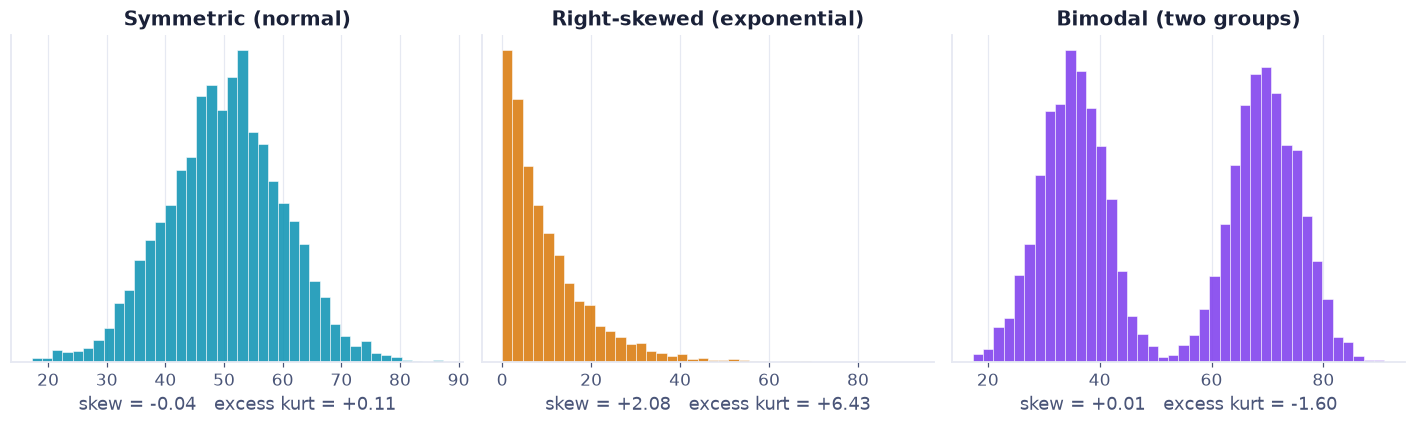

Right-skew: skew > 0. Bimodal: skew near 0 but clearly NOT symmetric, the number can mislead, always plot.


In [2]:
symmetric = rng.normal(50, 10, 4000)                       # bell
right_skew = rng.exponential(10, 4000)                      # long right tail
bimodal = np.concatenate([rng.normal(35, 6, 2000),
                          rng.normal(70, 6, 2000)])         # two humps

sets = [("Symmetric (normal)", symmetric, CYAN),
        ("Right-skewed (exponential)", right_skew, AMBER),
        ("Bimodal (two groups)", bimodal, PURPLE)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax,(name,d,c) in zip(axes, sets):
    ax.hist(d, bins=40, color=c, alpha=0.85, edgecolor="white", linewidth=0.4)
    sk = stats.skew(d); ku = stats.kurtosis(d)   # kurtosis = EXCESS (normal ≈ 0)
    ax.set_title(name)
    ax.set_xlabel(f"skew = {sk:+.2f}   excess kurt = {ku:+.2f}")
    ax.set_yticks([])
plt.tight_layout(); plt.show()
print("Right-skew: skew > 0. Bimodal: skew near 0 but clearly NOT symmetric, the number can mislead, always plot.")

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE MEAN CHASES THE TAIL</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">⚖️ Why skew splits mean and median</div>
<div style="color:#4a5578;margin-top:6px">On a right-skewed distribution the long tail drags the mean upward, while the median stays put in the bulk. That gap (mean minus median) is itself a quick skew signal.</div>
</div>

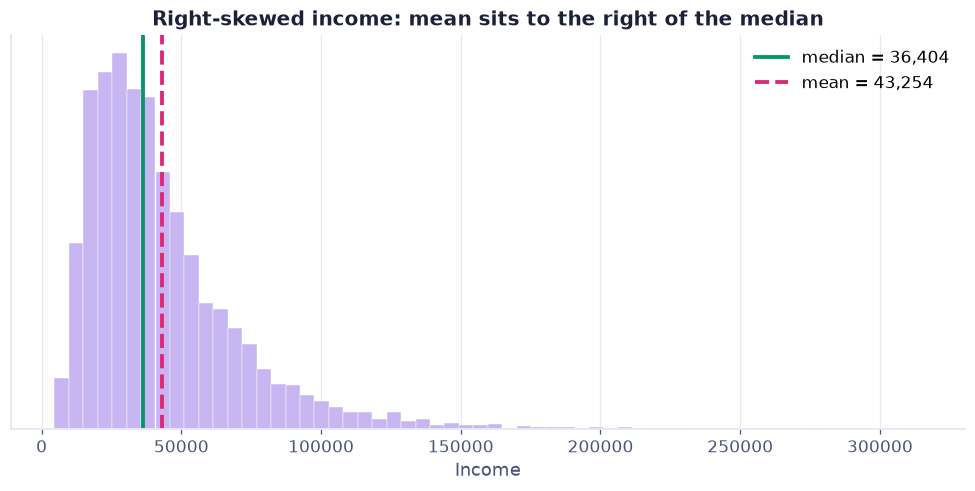

mean - median = 6,850  (positive → right skew)
For skewed money data, report the MEDIAN: the mean overstates the typical case.


In [3]:
income = rng.lognormal(mean=10.5, sigma=0.6, size=5000)    # income-like, right-skewed
mean_, median_ = income.mean(), np.median(income)

fig, ax = plt.subplots(figsize=(9,4.6))
ax.hist(income, bins=60, color="#c7b6f2", edgecolor="white", linewidth=0.3)
ax.axvline(median_, color=GREEN, lw=2.5, label=f"median = {median_:,.0f}")
ax.axvline(mean_,   color=PINK,  lw=2.5, ls="--", label=f"mean = {mean_:,.0f}")
ax.set_title("Right-skewed income: mean sits to the right of the median")
ax.set_xlabel("Income"); ax.set_yticks([]); ax.legend()
plt.tight_layout(); plt.show()
print(f"mean - median = {mean_-median_:,.0f}  (positive → right skew)")
print("For skewed money data, report the MEDIAN: the mean overstates the typical case.")

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · KURTOSIS IS ABOUT TAILS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🎯 Heavy tails, not a tall peak</div>
<div style="color:#4a5578;margin-top:6px">The common textbook line that kurtosis measures peakedness is wrong. It measures tail extremity: how outlier-prone the data is. Here a heavy-tailed sample and a normal sample share the SAME variance, yet one throws far more extreme values.</div>
</div>

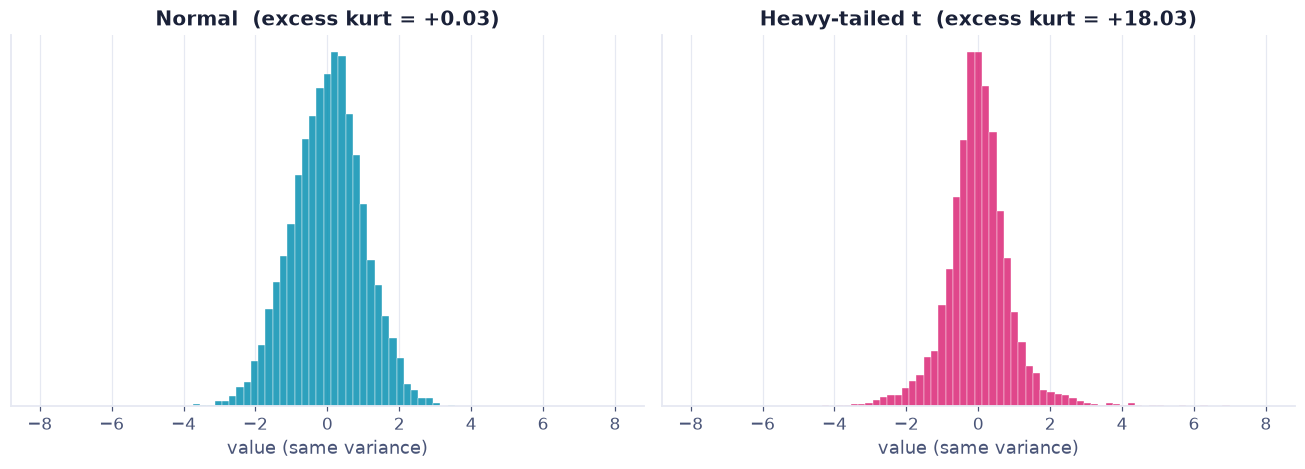

Most extreme |value|  normal: 3.7   heavy-tailed: 13.9
Same spread, but the leptokurtic sample reaches much farther out. High kurtosis = outlier risk.


In [4]:
normal_s = rng.normal(0, 1, 6000)
heavy = stats.t.rvs(df=3, size=6000, random_state=rng)
heavy = heavy / heavy.std()        # rescale so both have variance ≈ 1

fig, (a1,a2) = plt.subplots(1, 2, figsize=(12, 4.4))
bins = np.linspace(-8, 8, 80)
a1.hist(normal_s, bins=bins, color=CYAN,  alpha=0.85, edgecolor="white", linewidth=0.3)
a1.set_title(f"Normal  (excess kurt = {stats.kurtosis(normal_s):+.2f})")
a2.hist(heavy,    bins=bins, color=PINK,  alpha=0.85, edgecolor="white", linewidth=0.3)
a2.set_title(f"Heavy-tailed t  (excess kurt = {stats.kurtosis(heavy):+.2f})")
for ax in (a1,a2): ax.set_yticks([]); ax.set_xlabel("value (same variance)")
plt.tight_layout(); plt.show()
print(f"Most extreme |value|  normal: {np.abs(normal_s).max():.1f}   heavy-tailed: {np.abs(heavy).max():.1f}")
print("Same spread, but the leptokurtic sample reaches much farther out. High kurtosis = outlier risk.")

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · TWO HUMPS, TWO GROUPS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔍 Modality as a data-detective clue</div>
<div style="color:#4a5578;margin-top:6px">A single summary can hide structure. When a histogram shows two peaks, it is often two subpopulations mixed together. Split them and the story becomes clear.</div>
</div>

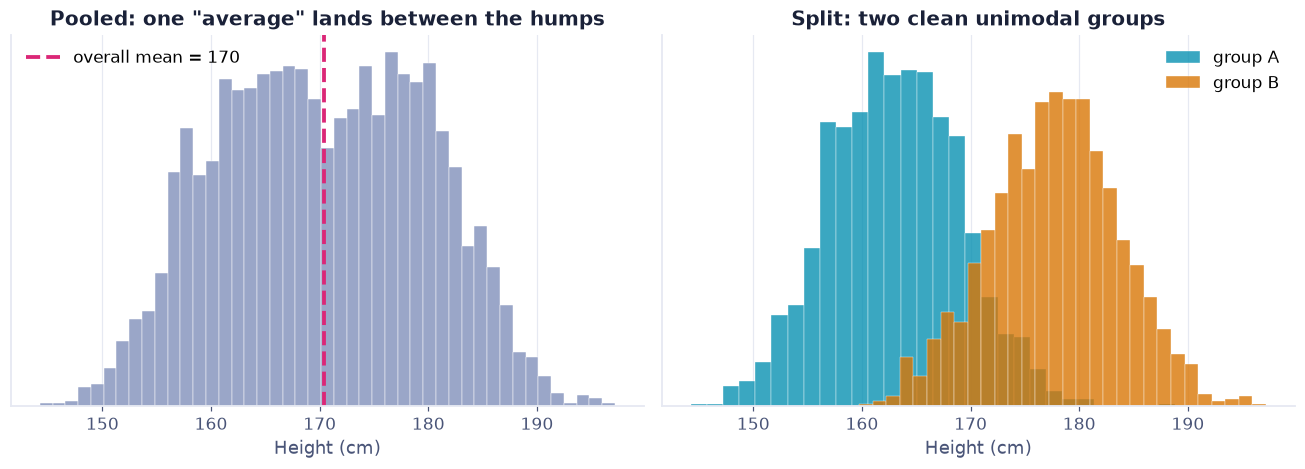

The overall mean 170 cm describes almost nobody, it sits in the valley between groups.


In [5]:
group_a = rng.normal(163, 6, 1500)    # one subpopulation
group_b = rng.normal(178, 6, 1500)    # another
heights = np.concatenate([group_a, group_b])

fig, (a1,a2) = plt.subplots(1, 2, figsize=(12, 4.4))
a1.hist(heights, bins=45, color="#9aa6c8", edgecolor="white", linewidth=0.3)
a1.axvline(heights.mean(), color=PINK, lw=2.5, ls="--", label=f"overall mean = {heights.mean():.0f}")
a1.set_title("Pooled: one \"average\" lands between the humps"); a1.legend(); a1.set_yticks([])
a2.hist(group_a, bins=30, color=CYAN,  alpha=0.8, edgecolor="white", linewidth=0.3, label="group A")
a2.hist(group_b, bins=30, color=AMBER, alpha=0.8, edgecolor="white", linewidth=0.3, label="group B")
a2.set_title("Split: two clean unimodal groups"); a2.legend(); a2.set_yticks([])
for ax in (a1,a2): ax.set_xlabel("Height (cm)")
plt.tight_layout(); plt.show()
print(f"The overall mean {heights.mean():.0f} cm describes almost nobody, it sits in the valley between groups.")

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · TAMING A LONG TAIL</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🪜 The log transform</div>
<div style="color:#4a5578;margin-top:6px">Right-skewed positive data (income, prices, counts) often straightens out under a log transform: it compresses the large values and pulls the tail in. Note: log needs strictly positive values.</div>
</div>

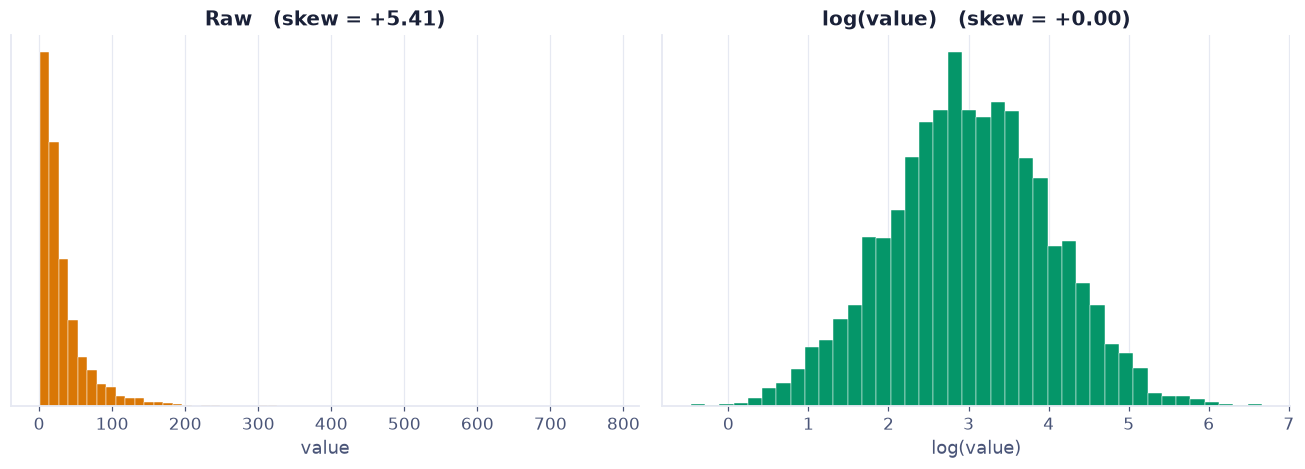

Skew drops toward 0: the logged data is nearly symmetric.
Caveat: log is undefined at 0 or negatives, use log1p or a shift for those, and remember you are now on a log scale.


In [6]:
raw = rng.lognormal(mean=3.0, sigma=1.0, size=5000)   # strongly right-skewed, all positive
logged = np.log(raw)

fig, (a1,a2) = plt.subplots(1, 2, figsize=(12, 4.4))
a1.hist(raw, bins=60, color=AMBER, edgecolor="white", linewidth=0.3)
a1.set_title(f"Raw   (skew = {stats.skew(raw):+.2f})"); a1.set_yticks([]); a1.set_xlabel("value")
a2.hist(logged, bins=40, color=GREEN, edgecolor="white", linewidth=0.3)
a2.set_title(f"log(value)   (skew = {stats.skew(logged):+.2f})"); a2.set_yticks([]); a2.set_xlabel("log(value)")
plt.tight_layout(); plt.show()
print("Skew drops toward 0: the logged data is nearly symmetric.")
print("Caveat: log is undefined at 0 or negatives, use log1p or a shift for those, and remember you are now on a log scale.")

## 💰 Real-World Example: The Shape of Insurance Claims
Insurance claims are a classic heavy-tailed distribution: most are modest, a few are huge. Here we measure the **skewness** and **kurtosis** of 600 real-shaped claims, then watch a **log transform** pull the long tail in and turn the lopsided shape into a near-symmetric one, the move that lets a symmetry-assuming model cope.

mean $2,052   median $1,723   (mean above median -> right skew)
skewness = 3.70   excess kurtosis = 28.20   (both large: long, heavy right tail)
after log transform: skewness = -0.06   (close to 0 -> nearly symmetric)


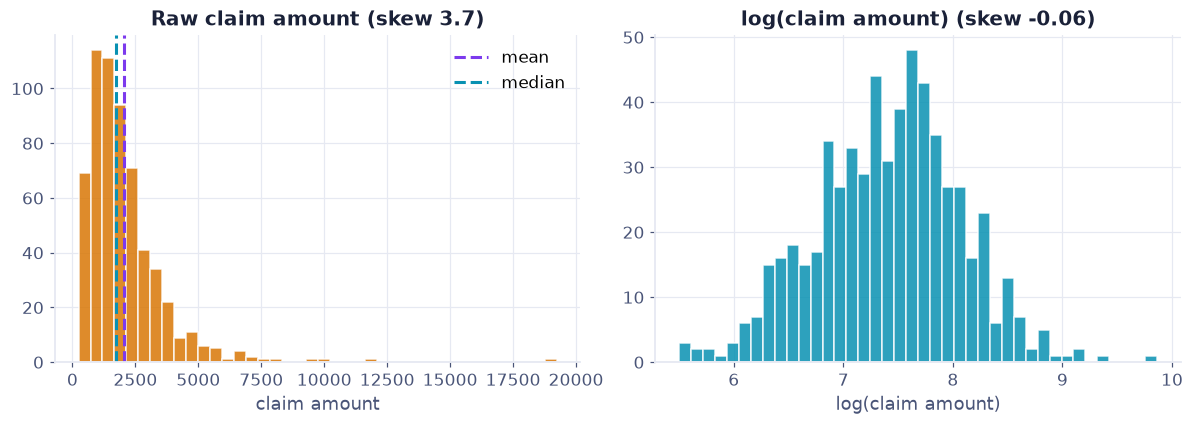

In [7]:
# --- Real-World beat: skewness, kurtosis, and the log-transform fix ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    claims = pd.read_excel("../../data/ch11_insurance_claims.xlsx", sheet_name="Data")
except FileNotFoundError: claims = pd.read_excel(BASE+"ch11_insurance_claims.xlsx", sheet_name="Data")
amt = claims.claim_amount
print(f"mean ${amt.mean():,.0f}   median ${amt.median():,.0f}   (mean above median -> right skew)")
print(f"skewness = {amt.skew():.2f}   excess kurtosis = {amt.kurt():.2f}   (both large: long, heavy right tail)")
print(f"after log transform: skewness = {np.log(amt).skew():.2f}   (close to 0 -> nearly symmetric)")
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].hist(amt, bins=40, color=AMBER, alpha=0.85, edgecolor="white")
ax[0].axvline(amt.mean(), color=PURPLE, ls="--", lw=2, label="mean")
ax[0].axvline(amt.median(), color=CYAN, ls="--", lw=2, label="median")
ax[0].set_title(f"Raw claim amount (skew {amt.skew():.1f})"); ax[0].set_xlabel("claim amount"); ax[0].legend()
ax[1].hist(np.log(amt), bins=40, color=CYAN, alpha=0.85, edgecolor="white")
ax[1].set_title(f"log(claim amount) (skew {np.log(amt).skew():.2f})"); ax[1].set_xlabel("log(claim amount)")
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Skewness</b> measures asymmetry: positive = long right tail, negative = long left tail. Name skew by the tail.</li>
<li>Under skew the <b>mean chases the tail</b>, so mean and median split; report the median for skewed data.</li>
<li><b>Kurtosis is about tails</b> (outlier-proneness), not peak height. scipy returns excess kurtosis, normal ≈ 0.</li>
<li>A <b>bimodal</b> shape usually means two subpopulations are mixed: disaggregate them.</li>
<li>A <b>log transform</b> pulls in a long right tail for strictly positive data.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>